In [1]:
import json

import h5py
import numpy as np

In [2]:
import matplotlib as mpl
from matplotlib import pyplot as plt

# define matplotlib style
plt.style.use("classic")
mpl.rc("xtick", labelsize=23)
mpl.rc("ytick", labelsize=23)
mpl.rc("xtick.major", size=15, width=2)
mpl.rc("xtick.minor", size=8, width=2, visible=True)
mpl.rc("ytick.major", size=15, width=2)
mpl.rc("ytick.minor", size=8, width=2, visible=True)
mpl.rc("lines", linewidth=3, markersize=20)
mpl.rc("axes", linewidth=2, labelsize=30, labelpad=2.5)
mpl.rc("legend", fontsize=25, loc="best", frameon=False, numpoints=1)

mpl.rc("font", family="STIXGeneral")
mpl.rc("mathtext", fontset="stix")

In [3]:
from luminareionization import fitting, fourier, utils

In [4]:
import importlib

importlib.reload(fitting)
importlib.reload(fourier)
importlib.reload(utils)

<module 'luminareionization.utils' from '/Users/vinhtran/Data/Research/Mark/Reionization Redshift/LuminaReionization/src/luminareionization/utils.py'>

In [5]:
L_box = 500
N_cell = 640
N_part = 2 * 6000**3

fourier_transform = fourier.FourierTransform(N_cell, L_box, N_part)

In [6]:
if False:
    z_reion_file = "../../Data/z_reion_V_99.hdf5"
    rho_dm_file = "../../Data/DensityDM_281.hdf5"

    z_reion_data = h5py.File(z_reion_file, "r")
    rho_dm_data = h5py.File(rho_dm_file, "r")

    z_reion_field = z_reion_data["ReionizationRedshift"][:]
    z_reion_mean = np.mean(z_reion_field)

    delta_z_reion = (z_reion_field - z_reion_mean) / (1 + z_reion_mean)

    k_mag, delta_z_reion_fourier = fourier_transform.fourier_transform(delta_z_reion)
    fourier_transform.save_fourier_transform(
        k_mag, delta_z_reion_fourier, "../../Data/z_reion_V_99_fourier.h5"
    )

    rho_dm_field = rho_dm_data["DensityDM"][:]
    rho_dm_mean = np.mean(rho_dm_field)

    delta_rho_dm = (rho_dm_field - rho_dm_mean) / rho_dm_mean

    k_mag, delta_rho_dm_fourier = fourier_transform.fourier_transform(delta_rho_dm)
    fourier_transform.save_fourier_transform(
        k_mag, delta_rho_dm_fourier, "../../Data/DensityDM_281_fourier.h5"
    )

In [7]:
if True:
    z_reion_fourier_file = "../../Data/z_reion_V_99_fourier.h5"
    rho_dm_fourier_file = "../../Data/DensityDM_281_fourier.h5"

    with h5py.File(z_reion_fourier_file, "r") as f:
        k_mag = f["WaveVector"][:]
        delta_z_reion_fourier = f["FourierTransform"][:]

    with h5py.File(rho_dm_fourier_file, "r") as f:
        delta_rho_dm_fourier = f["FourierTransform"][:]

    k_bins, P_zz, P_zz_err = fourier_transform.get_power_spectrum(
        k_mag=k_mag,
        delta_k_1=delta_z_reion_fourier,
    )
    fourier_transform.save_power_spectrum(
        k_bins, P_zz, P_zz_err, "../../Data/z_reion_V_99_power_spectrum.json"
    )

    k_bins, P_mm, P_mm_err = fourier_transform.get_power_spectrum(
        k_mag=k_mag, delta_k_1=delta_rho_dm_fourier
    )
    fourier_transform.save_power_spectrum(
        k_bins, P_mm, P_mm_err, "../../Data/DensityDM_281_power_spectrum.json"
    )

    k_bins, P_mz, P_mz_err = fourier_transform.get_power_spectrum(
        k_mag=k_mag,
        delta_k_1=delta_rho_dm_fourier,
        delta_k_2=delta_z_reion_fourier,
        P_k_11_raw=P_mm + fourier_transform._P_shot,
        P_k_22_raw=P_zz + fourier_transform._P_shot,
    )
    fourier_transform.save_power_spectrum(
        k_bins,
        P_mz,
        P_mz_err,
        "../../Data/DensityDM_281_z_reion_V_99_cross_power_spectrum.json",
    )

In [8]:
with open("../../Data/z_reion_V_99_power_spectrum.json") as f:  # noqa: PTH123
    _power_spectrum_dict = json.load(f)

    for key in _power_spectrum_dict:
        _power_spectrum_dict[key] = np.array(_power_spectrum_dict[key])

    k_bins = _power_spectrum_dict["k_bins"]
    P_zz = _power_spectrum_dict["P_k"]
    P_zz_err = _power_spectrum_dict["P_k_err"]

with open("../../Data/DensityDM_281_power_spectrum.json") as f:  # noqa: PTH123
    _power_spectrum_dict = json.load(f)

    for key in _power_spectrum_dict:
        _power_spectrum_dict[key] = np.array(_power_spectrum_dict[key])

    k_bins = _power_spectrum_dict["k_bins"]
    P_mm = _power_spectrum_dict["P_k"]
    P_mm_err = _power_spectrum_dict["P_k_err"]

with open("../../Data/DensityDM_281_z_reion_V_99_cross_power_spectrum.json") as f:  # noqa: PTH123
    _power_spectrum_dict = json.load(f)

    for key in _power_spectrum_dict:
        _power_spectrum_dict[key] = np.array(_power_spectrum_dict[key])

    k_bins = _power_spectrum_dict["k_bins"]
    P_mz = _power_spectrum_dict["P_k"]
    P_mz_err = _power_spectrum_dict["P_k_err"]

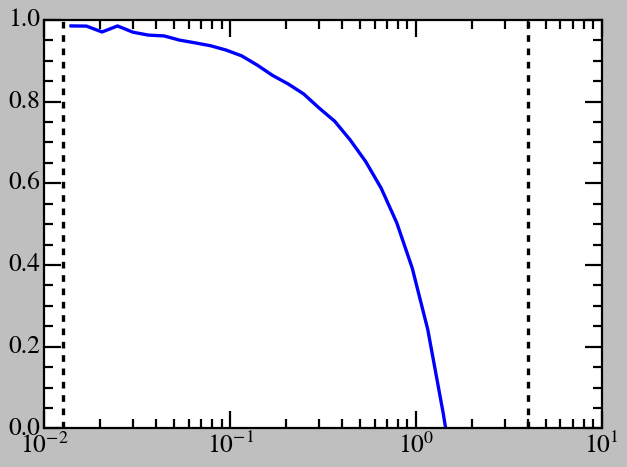

In [9]:
plt.plot(k_bins, P_mz / np.sqrt(P_mm * P_zz))

plt.axvline(fourier_transform._k_min, color="k", linestyle="--")
plt.axvline(fourier_transform._k_max, color="k", linestyle="--")

plt.xscale("log")
# plt.yscale("log")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

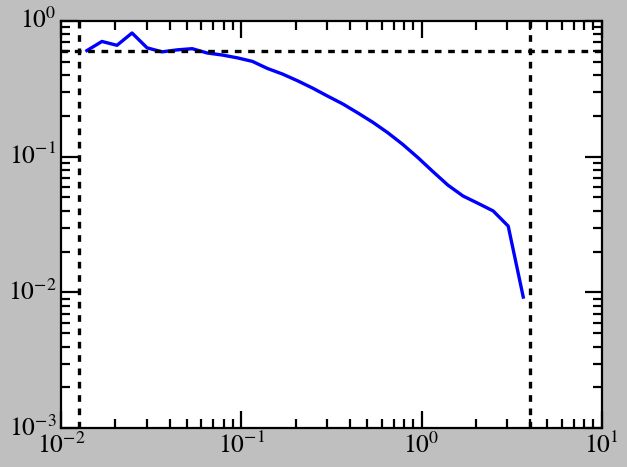

In [10]:
plt.plot(k_bins, np.sqrt(P_zz / P_mm))

plt.axvline(fourier_transform._k_min, color="k", linestyle="--")
plt.axvline(fourier_transform._k_max, color="k", linestyle="--")

plt.axhline(0.593, color="k", linestyle="--")

plt.xscale("log")
plt.yscale("log")

plt.tight_layout()
plt.show()